# Parte 5 — Comparación de Estrategias
### Fine-tuning Completo · Feature Extraction · LoRA

Este notebook es **independiente** — carga los tres modelos directamente desde Hugging Face Hub y los evalúa sobre el mismo test set.

No necesita haber ejecutado los notebooks anteriores en la misma sesión.

In [ ]:
# !pip install 'transformers[torch]' 'accelerate>=1.1.0' datasets evaluate scikit-learn matplotlib -q

In [4]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from datasets import load_dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)
import evaluate
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# ── Cambia estos repos por los tuyos ──────────────────────────────────────────
MODELS = {
    "Full fine-tuning":  "jdmartinev/imdb-distilbert-full",
    "Feature extraction": "jdmartinev/imdb-distilbert-head-only",
    "LoRA (r=8)":        "jdmartinev/imdb-distilbert-lora",
}

SEED        = 42
SUBSET_SIZE = 10_000
MAX_LENGTH  = 256
BATCH_SIZE  = 32
ID2LABEL    = {0: "negative", 1: "positive"}
LABEL2ID    = {"negative": 0, "positive": 1}
COLORS      = ["#3498db", "#e74c3c", "#2ecc71"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 1. Preparar test set

Cargamos el dataset original y construimos el split de test — mismo proceso que en `part-1-data.ipynb` para garantizar consistencia.

In [5]:
raw = load_dataset("imdb")

if SUBSET_SIZE:
    raw["test"] = raw["test"].shuffle(seed=SEED).select(range(SUBSET_SIZE // 5))

# Usamos el tokenizador de cualquiera de los modelos — todos usan distilbert-base-uncased
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def preprocess(examples):
    texts = [re.sub(r"<[^>]+>", " ", t) for t in examples["text"]]
    return tokenizer(texts, truncation=True, max_length=MAX_LENGTH)

test_ds = raw["test"].map(preprocess, batched=True, remove_columns=["text"])
print(f"Test set: {len(test_ds):,} ejemplos")

Test set: 2,000 ejemplos


## 2. Evaluar cada modelo desde Hub

In [6]:
acc_metric = evaluate.load("accuracy")
f1_metric  = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": acc_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1_macro": f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"],
    }


def evaluate_from_hub(hub_repo: str, name: str) -> dict:
    """Carga un modelo desde Hub, evalúa en test y devuelve métricas + predicciones."""
    print(f"\nCargando {name} desde {hub_repo} ...")

    model = AutoModelForSequenceClassification.from_pretrained(
        hub_repo, num_labels=2, id2label=ID2LABEL, label2id=LABEL2ID)

    n_params = sum(p.numel() for p in model.parameters())
    n_total     = sum(p.numel() for p in model.parameters())
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

    # Trainer mínimo — solo para inferencia
    args = TrainingArguments(
        output_dir="/tmp/eval",
        per_device_eval_batch_size=BATCH_SIZE,
        report_to="none",
        fp16=torch.cuda.is_available(),
    )
    trainer = Trainer(
        model=model,
        args=args,
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=compute_metrics,
    )

    output = trainer.predict(test_ds)
    preds  = np.argmax(output.predictions, axis=1)

    print(f"  accuracy={output.metrics['test_accuracy']:.4f}  f1_macro={output.metrics['test_f1_macro']:.4f}")

    return {
        "name":               name,
        "n_params":           n_total,
        "n_params_trainable": n_trainable,
        "pct_trainable":      n_trainable / n_total * 100,
        "f1_macro":           output.metrics["test_f1_macro"],
        "accuracy":           output.metrics["test_accuracy"],
        "preds":              preds,
        "labels":             output.label_ids,
    }

results = [evaluate_from_hub(repo, name) for name, repo in MODELS.items()]
print("\nEvaluación completa.")


Cargando Full fine-tuning desde jdmartinev/imdb-distilbert-full ...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

  accuracy=0.8950  f1_macro=0.8950

Cargando Feature extraction desde jdmartinev/imdb-distilbert-head-only ...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

  accuracy=0.8235  f1_macro=0.8234

Cargando LoRA (r=8) desde jdmartinev/imdb-distilbert-lora ...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

  accuracy=0.8880  f1_macro=0.8880

Evaluación completa.


## 3. Tabla comparativa

In [7]:
df_results = pd.DataFrame([
    {
        "Estrategia":   r["name"],
        "Parámetros":   f"{r['n_params']/1e6:.1f}M",
        "Accuracy":     f"{r['accuracy']:.4f}",
        "F1 Macro":     f"{r['f1_macro']:.4f}",
    }
    for r in results
])

print(df_results.to_string(index=False))

        Estrategia Parámetros Accuracy F1 Macro
  Full fine-tuning      67.0M   0.8950   0.8950
Feature extraction      67.0M   0.8235   0.8234
        LoRA (r=8)      67.0M   0.8880   0.8880


## 4. Gráfico comparativo

/tmp/ipykernel_3162/3383155782.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(names, rotation=10)


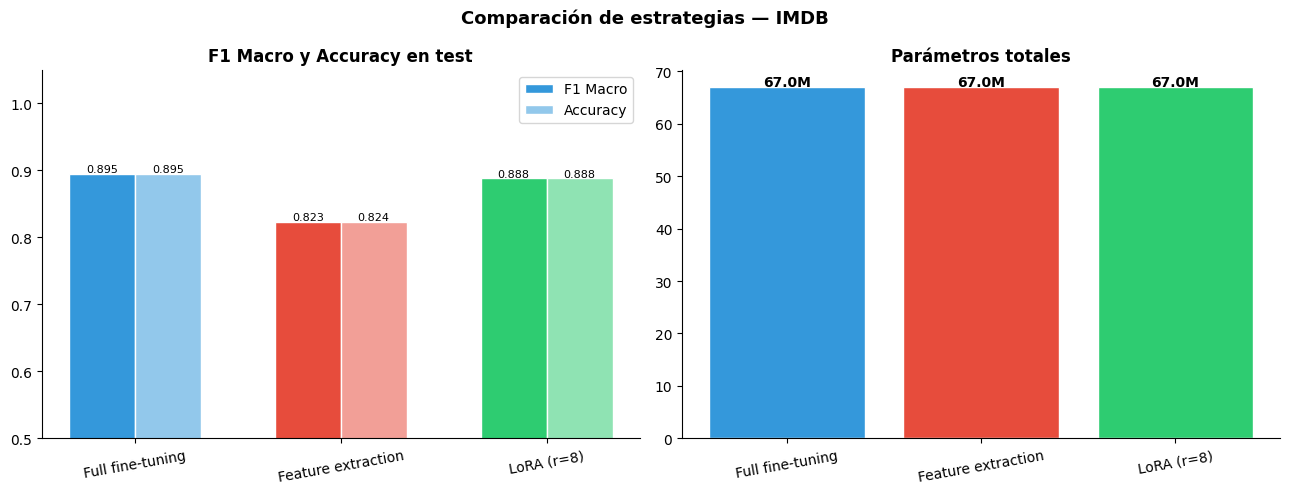

In [8]:
names   = [r["name"] for r in results]
f1s     = [r["f1_macro"]  for r in results]
accs    = [r["accuracy"]  for r in results]
params  = [r["n_params"]  for r in results]
x       = np.arange(len(names))
w       = 0.32

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Métricas
bars1 = axes[0].bar(x - w/2, f1s,  w, label="F1 Macro",
                    color=COLORS, edgecolor="white")
bars2 = axes[0].bar(x + w/2, accs, w, label="Accuracy",
                    color=[c + "88" for c in COLORS], edgecolor="white")
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.002,
                     f"{h:.3f}", ha="center", fontsize=8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=10)
axes[0].set_ylim(0.5, 1.05)
axes[0].set_title("F1 Macro y Accuracy en test", fontweight="bold")
axes[0].legend()
axes[0].spines[["top", "right"]].set_visible(False)

# Parámetros
bars3 = axes[1].bar(names, [p/1e6 for p in params], color=COLORS, edgecolor="white")
for bar, p in zip(bars3, params):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{p/1e6:.1f}M", ha="center", fontweight="bold")
axes[1].set_title("Parámetros totales", fontweight="bold")
axes[1].set_xticklabels(names, rotation=10)
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle("Comparación de estrategias — IMDB", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Confusion matrices lado a lado

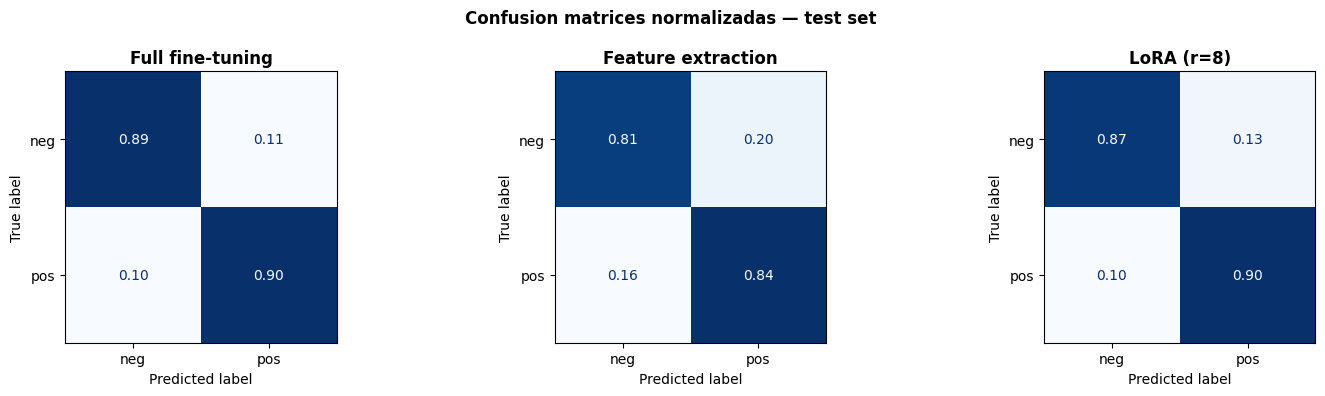

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, r in zip(axes, results):
    cm = confusion_matrix(r["labels"], r["preds"])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    ConfusionMatrixDisplay(cm_norm, display_labels=["neg", "pos"]).plot(
        ax=ax, colorbar=False, cmap="Blues", values_format=".2f")
    ax.set_title(r["name"], fontweight="bold")

plt.suptitle("Confusion matrices normalizadas — test set", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Classification reports

In [10]:
for r in results:
    print(f"\n{'='*55}")
    print(f"  {r['name']}")
    print(f"{'='*55}")
    print(classification_report(
        r["labels"], r["preds"],
        target_names=["negative", "positive"],
        digits=4,
    ))


  Full fine-tuning
              precision    recall  f1-score   support

    negative     0.8958    0.8940    0.8949      1000
    positive     0.8942    0.8960    0.8951      1000

    accuracy                         0.8950      2000
   macro avg     0.8950    0.8950    0.8950      2000
weighted avg     0.8950    0.8950    0.8950      2000


  Feature extraction
              precision    recall  f1-score   support

    negative     0.8359    0.8050    0.8202      1000
    positive     0.8120    0.8420    0.8267      1000

    accuracy                         0.8235      2000
   macro avg     0.8239    0.8235    0.8234      2000
weighted avg     0.8239    0.8235    0.8234      2000


  LoRA (r=8)
              precision    recall  f1-score   support

    negative     0.8992    0.8740    0.8864      1000
    positive     0.8774    0.9020    0.8895      1000

    accuracy                         0.8880      2000
   macro avg     0.8883    0.8880    0.8880      2000
weighted avg     0

## 7. Análisis de errores — ejemplos donde los modelos difieren

In [11]:
# Reconstruir el test set con texto original para el análisis
raw_test = load_dataset("imdb", split="test")
if SUBSET_SIZE:
    raw_test = raw_test.shuffle(seed=SEED).select(range(SUBSET_SIZE // 5))

df_errors = pd.DataFrame({
    "text":        raw_test["text"],
    "true_label":  [ID2LABEL[l] for l in results[0]["labels"]],
})

for r in results:
    df_errors[r["name"]] = [ID2LABEL[p] for p in r["preds"]]
    df_errors[f"{r['name']}_ok"] = df_errors[r["name"]] == df_errors["true_label"]

# Ejemplos donde LoRA acierta pero full FT falla
full_col = results[0]["name"]
lora_col = results[2]["name"]

lora_wins = df_errors[
    ~df_errors[f"{full_col}_ok"] & df_errors[f"{lora_col}_ok"]
][["text", "true_label", full_col, lora_col]].head(3)

print(f"Ejemplos donde LoRA acierta pero Full FT falla ({len(lora_wins)} mostrados):")
for _, row in lora_wins.iterrows():
    print(f"\n  True: {row['true_label']}  |  Full FT: {row[full_col]}  |  LoRA: {row[lora_col]}")
    print(f"  {row['text'][:200]}...")

Ejemplos donde LoRA acierta pero Full FT falla (3 mostrados):

  True: positive  |  Full FT: negative  |  LoRA: positive
  i was having a horrid day but this movie grabbed me, and i couldn't put it down until the end... and i had forgotten about my horrid day. and the ending... by the way... where is the sequel!!!<br /><b...

  True: positive  |  Full FT: negative  |  LoRA: positive
  OK...ths film (like Segal's last few films) once again goes beyond the "knock 'em down, kick 'em in the groin, shoot 'em in the face, get revenge against the bad guys for hurting my sister's niece's c...

  True: positive  |  Full FT: negative  |  LoRA: positive
  This is a cute little French silent comedy about a man who bets another that he can't stay in this castle for one hour due to its being haunted. And, once the guy enters the house, it looks much more ...


## 8. Resumen

| Estrategia | Parámetros entrenables | Calidad | Cuándo usarlo |
|---|---|---|---|
| **Full fine-tuning** | ~100% | Alta | Datos suficientes, GPU disponible |
| **Feature extraction** | ~0.15% | Baja–media | Muy pocos datos, sin GPU |
| **LoRA (r=8)** | ~1–3% | Alta | Balance costo/calidad, producción |